# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [45]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [46]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations

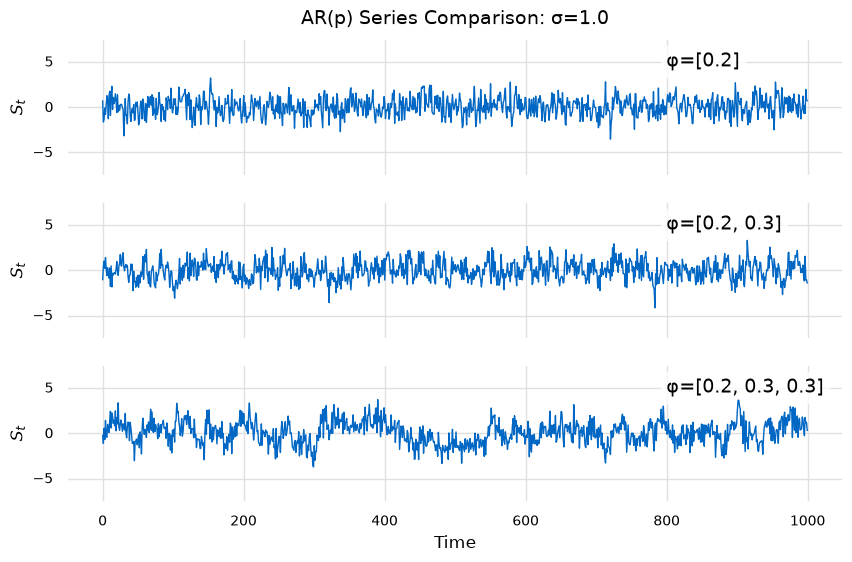

In [47]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [48]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.22716337]))

In [49]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1410.668
Date:                Sun, 30 Aug 2026   AIC                           2827.336
Time:                        11:53:04   BIC                           2842.059
Sample:                             0   HQIC                          2832.932
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0459      0.041      1.132      0.258      -0.034       0.125
ar.L1          0.2271      0.031      7.298      0.000       0.166       0.288
sigma2         0.9835      0.046     21.438      0.000       0.894       1.073
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.12
Prob(Q):                              0.91   Prob(JB):                         0.57
Heteroskedasticity (H):               0.94   Skew:                            -0.02
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [50]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.04593883242427853,
      "err": 0.04057854870878227,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "27bd98b9-f192-40d5-8b5a-596c4c5372bd",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.2271244941388179,
         "err": 0.03112298536237194,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "27bd98b9-f192-40d5-8b5a-596c4c5372bd",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 0.9835406269239235,
      "err": 0.04587798506962765,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      

### AR(2) Example $\varphi = [0.2, 0.3]$

In [51]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.19829814, 0.31648121]))

In [52]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1389.498
Date:                Sun, 30 Aug 2026   AIC                           2786.996
Time:                        11:53:04   BIC                           2806.627
Sample:                             0   HQIC                          2794.457
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0351      0.064     -0.550      0.583      -0.160       0.090
ar.L1          0.1985      0.032      6.245      0.000       0.136       0.261
ar.L2          0.3171      0.031     10.235      0.000       0.256       0.378
sigma2         0.9425      0.045     20.882      0.000       0.854       1.031
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 6.22
Prob(Q):                              0.82   Prob(JB):                         0.04
Heteroskedasticity (H):               0.99   Skew:                             0.15
Prob(H) (two-sided):                  0.93   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.0351315338558876,
      "err": 0.06391726205934083,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5588b9c2-9d97-4b59-ad97-1186cd26321e",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.19851805690975907,
         "err": 0.03178999817616248,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "5588b9c2-9d97-4b59-ad97-1186cd26321e",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.3170716759997898,
         "err": 0.030978331556701558,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         "

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [54]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.21144794, 0.27621055, 0.28870352]))

In [55]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1400.318
Date:                Sun, 30 Aug 2026   AIC                           2810.637
Time:                        11:53:04   BIC                           2835.176
Sample:                             0   HQIC                          2819.963
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0845      0.138      0.611      0.541      -0.187       0.356
ar.L1          0.2105      0.031      6.851      0.000       0.150       0.271
ar.L2          0.2763      0.030      9.295      0.000       0.218       0.335
ar.L3          0.2889      0.031      9.377      0.000       0.228       0.349
sigma2         0.9626      0.042     22.731      0.000       0.880       1.046
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.82
Prob(Q):                              0.96   Prob(JB):                         0.66
Heteroskedasticity (H):               0.95   Skew:                            -0.05
Prob(H) (two-sided):                  0.67   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [56]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.08452192801716041,
      "err": 0.13831593355842886,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "155a6a42-9ad9-41b5-81e0-7237ef8a496a",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.21051445691690407,
         "err": 0.030725826491218834,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "155a6a42-9ad9-41b5-81e0-7237ef8a496a",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.27628947866670855,
         "err": 0.02972438433410337,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         

## Simulations $\sigma = 5.0$

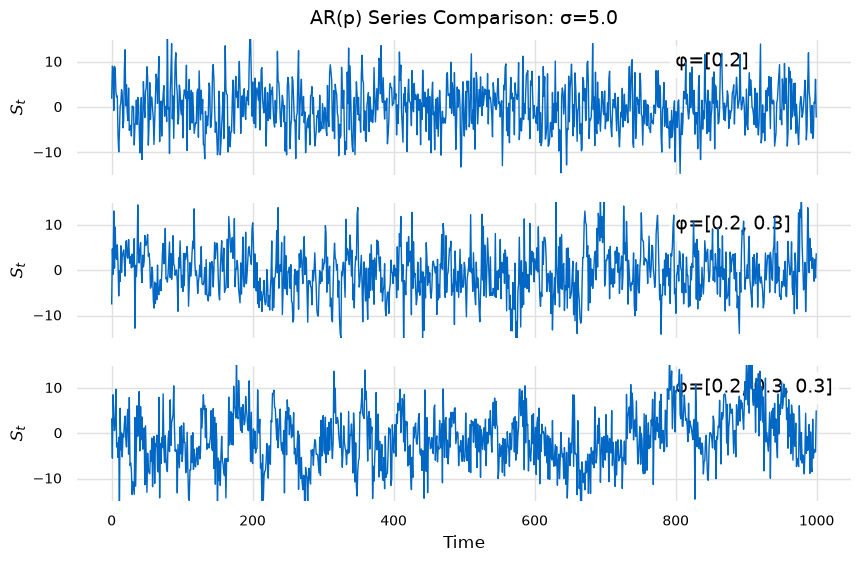

In [57]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [58]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.22310779]))

In [59]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3043.666
Date:                Sun, 30 Aug 2026   AIC                           6093.332
Time:                        11:53:05   BIC                           6108.055
Sample:                             0   HQIC                          6098.928
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0837      0.208      0.403      0.687      -0.324       0.491
ar.L1          0.2230      0.030      7.389      0.000       0.164       0.282
sigma2        25.7750      1.195     21.575      0.000      23.433      28.116
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.23
Prob(Q):                              0.86   Prob(JB):                         0.54
Heteroskedasticity (H):               0.83   Skew:                             0.05
Prob(H) (two-sided):                  0.10   Kurtosis:                         2.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.08374228766429569,
      "err": 0.20780526483596115,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "19aa5502-3f61-4484-b2bd-9442c56f9932",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.22296142763378968,
         "err": 0.030173337677636143,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "19aa5502-3f61-4484-b2bd-9442c56f9932",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.774955699491336,
      "err": 1.1946513707397337,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
     

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [61]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.1974896 , 0.29055372]))

In [62]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3029.861
Date:                Sun, 30 Aug 2026   AIC                           6067.723
Time:                        11:53:05   BIC                           6087.354
Sample:                             0   HQIC                          6075.184
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3159      0.309     -1.021      0.307      -0.922       0.290
ar.L1          0.1971      0.030      6.568      0.000       0.138       0.256
ar.L2          0.2907      0.030      9.642      0.000       0.232       0.350
sigma2        25.0679      1.080     23.201      0.000      22.950      27.186
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 2.89
Prob(Q):                              0.76   Prob(JB):                         0.24
Heteroskedasticity (H):               1.16   Skew:                             0.10
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [63]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.31589031063190115,
      "err": 0.3093482256182466,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9060ecc3-3b59-4ddc-bf27-04cb12a24d57",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.19713916803555676,
         "err": 0.03001494551829195,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "9060ecc3-3b59-4ddc-bf27-04cb12a24d57",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2906549157505714,
         "err": 0.03014477237990881,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         "o

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [64]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.10950939, 0.32575738, 0.31462373]))

In [65]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3029.324
Date:                Sun, 30 Aug 2026   AIC                           6068.648
Time:                        11:53:05   BIC                           6093.187
Sample:                             0   HQIC                          6077.975
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3160      0.300     -1.054      0.292      -0.904       0.272
ar.L1          0.2067      0.031      6.663      0.000       0.146       0.267
ar.L2          0.2972      0.031      9.506      0.000       0.236       0.358
ar.L3         -0.0327      0.032     -1.012      0.312      -0.096       0.031
sigma2        25.0425      1.079     23.203      0.000      22.927      27.158
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.74
Prob(Q):                              1.00   Prob(JB):                         0.25
Heteroskedasticity (H):               1.15   Skew:                             0.10
Prob(H) (two-sided):                  0.19   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [66]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.31603045494153237,
      "err": 0.2999198568723115,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "96c1b3f9-66e5-4447-88a9-99a69536a56a",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.20665291902819738,
         "err": 0.03101663946744258,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "96c1b3f9-66e5-4447-88a9-99a69536a56a",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.29718928234125225,
         "err": 0.03126366634705769,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         "